In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

BASE_PATH = "/content/drive/MyDrive"

VIDEO_FOLDER = os.path.join(BASE_PATH, "YouTubeClips")
OUTPUT_FILE = os.path.join(BASE_PATH, "features.npy")

MAX_FRAMES = 20

In [ ]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return []

    step = max(1, total_frames // MAX_FRAMES)

    count = 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)

        count += 1

    cap.release()
    return frames

In [ ]:
import numpy as np
import os
import cv2

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Input, Add, Activation, Dropout
)


VIDEO_FOLDER = "data/YouTubeClips"
MAX_FRAMES = 20


def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x



def build_strong_cnn():
    inputs = Input(shape=(224,224,3))

    x = Conv2D(64, (7,7), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128)
    x = MaxPooling2D()(x)

    x = residual_block(x, 128)
    x = residual_block(x, 256)
    x = MaxPooling2D()(x)

    x = residual_block(x, 256)
    x = residual_block(x, 512)

    x = GlobalAveragePooling2D()(x)

    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)

    model = Model(inputs, x)
    return model


cnn_model = build_strong_cnn()


def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // MAX_FRAMES)

    count = 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)

        count += 1

    cap.release()
    return frames



def extract_features_from_video(video_path):
    frames = extract_frames(video_path)

    features = []

    for frame in frames:
        frame = frame / 255.0
        frame = np.expand_dims(frame, axis=0)

        feature = cnn_model.predict(frame, verbose=0)
        features.append(feature.flatten())

    return np.array(features)



video_name = os.listdir(VIDEO_FOLDER)[0]
video_path = os.path.join(VIDEO_FOLDER, video_name)

features = extract_features_from_video(video_path)

print(features.shape)

In [ ]:
cnn_model = build_strong_cnn()

In [ ]:
def extract_features_from_video(video_path):
    frames = extract_frames(video_path)

    features = []

    for frame in frames:
        frame = frame / 255.0
        frame = np.expand_dims(frame, axis=0)

        feature = cnn_model.predict(frame, verbose=0)
        features.append(feature.flatten())

    return np.array(features)

In [ ]:
if os.path.exists(OUTPUT_FILE):
    all_features = np.load(OUTPUT_FILE, allow_pickle=True).item()
    print("Loaded existing:", len(all_features))
else:
    all_features = {}

video_list = os.listdir(VIDEO_FOLDER)

for i, video_name in enumerate(video_list):

    video_id = video_name.split('.')[0]

    if video_id in all_features:
        continue

    video_path = os.path.join(VIDEO_FOLDER, video_name)

    try:
        features = extract_features_from_video(video_path)
        all_features[video_id] = features

        print(f"[{i}/{len(video_list)}]  {video_name}")

        if len(all_features) % 20 == 0:
            np.save(OUTPUT_FILE, all_features)
            print("Saved progress")

    except Exception as e:
        print("Error:", video_name, e)

np.save(OUTPUT_FILE, all_features)

print("Done! Total:", len(all_features))

In [ ]:
import re



def load_captions(path):
    mapping = {}

    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split(' ', 1)

            if len(parts) < 2:
                continue

            video_id = parts[0].split('#')[0]
            caption = parts[1]

            if video_id not in mapping:
                mapping[video_id] = []

            mapping[video_id].append(caption)

    return mapping



def clean_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z ]", "", caption)
    caption = " ".join(caption.split())
    return "<start> " + caption + " <end>"



def clean_captions(mapping):
    for video_id, captions in mapping.items():
        mapping[video_id] = [clean_caption(c) for c in captions]
    return mapping



def build_vocab(mapping, min_freq=2):
    word_counts = {}


    for captions in mapping.values():
        for caption in captions:
            for word in caption.split():
                word_counts[word] = word_counts.get(word, 0) + 1

    vocab = [w for w in word_counts if word_counts[w] >= min_freq]

    word_to_index = {w: i+1 for i, w in enumerate(vocab)}
    index_to_word = {i+1: w for i, w in enumerate(vocab)}

    return word_to_index, index_to_word



def caption_to_seq(caption, word_to_index):
    return [word_to_index[w] for w in caption.split() if w in word_to_index]



def get_max_length(mapping):
    max_len = 0
    for captions in mapping.values():
        for caption in captions:
            max_len = max(max_len, len(caption.split()))
    return max_len



def prepare_text_data(captions_path):
    captions = load_captions(captions_path)
    captions = clean_captions(captions)

    word_to_index, index_to_word = build_vocab(captions)
    max_len = get_max_length(captions)

    return captions, word_to_index, index_to_word, max_len


captions, w2i, i2w, max_len = prepare_text_data("/content/drive/MyDrive/annotations.txt")

print("Captions:", len(captions))
print("Vocab:", len(w2i))
print("Max length:", max_len)

Captions: 1970
Vocab: 7016
Max length: 47


In [ ]:
# filter_data.py

captions = {k: captions[k] for k in features.keys() if k in captions}

print("Filtered:", len(captions))

Filtered: 1970


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_generator(features, captions, w2i, max_len, batch_size=32):

    vocab_size = len(w2i) + 1

    while True:  # infinite loop for training

        X1, X2, y = [], [], []

        for video_id, caps in captions.items():
            feature = features[video_id]

            for cap in caps:
                seq = [w2i[w] for w in cap.split() if w in w2i]

                for i in range(1, len(seq)):

                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_len)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

In [ ]:
def count_samples(captions, w2i):
    count = 0

    for caps in captions.values():
        for cap in caps:
            seq = [w2i[w] for w in cap.split() if w in w2i]
            count += len(seq) - 1

    return count

total_samples = count_samples(captions, w2i)

print("Total samples:", total_samples)

Total samples: 643013


In [ ]:
batch_size = 32
steps = total_samples // batch_size

print("Steps per epoch:", steps)

Steps per epoch: 20094


In [ ]:
# model.py

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, add

vocab_size = len(w2i) + 1

video_input = Input(shape=(20, 2048))
x1 = LSTM(256)(video_input)

text_input = Input(shape=(max_len,))
x2 = Embedding(vocab_size, 256)(text_input)
x2 = LSTM(256)(x2)
decoder = add([x1, x2])

output = Dense(vocab_size, activation='softmax')(decoder)

model = Model(inputs=[video_input, text_input], outputs=output)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 47)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 20, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 47, 256)   │  1,796,352 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 256)       │  2,360,320 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 256)       │    525,312 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ lstm_6[0][0],     │
│                     │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7017)      │  1,803,369 │ add_3[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,485,353 (24.74 MB)

 Trainable params: 6,485,353 (24.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
generator = data_generator(features, captions, w2i, max_len, batch_size=32)

model.fit(
    generator,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 376s 19ms/step - loss: 3.8585
Epoch 2/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 378s 19ms/step - loss: 3.3973
Epoch 3/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 377s 19ms/step - loss: 3.2091
Epoch 4/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 376s 19ms/step - loss: 3.0794
Epoch 5/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 376s 19ms/step - loss: 2.9472
Epoch 6/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 376s 19ms/step - loss: 2.8765
Epoch 7/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 373s 19ms/step - loss: 2.8612
Epoch 8/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 375s 19ms/step - loss: 2.7725
Epoch 9/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 371s 18ms/step - loss: 2.7136
Epoch 10/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 373s 19ms/step - loss: 2.6473


In [ ]:
model.save("/content/drive/MyDrive/video_caption_model.h5")

In [ ]:
import cv2
import os

MAX_FRAMES = 20

def generate_caption(model, feature, w2i, i2w, max_len):

    in_text = "<start>"

    for i in range(max_len):

        seq = [w2i[w] for w in in_text.split() if w in w2i]
        seq = pad_sequences([seq], maxlen=max_len)

        yhat = model.predict([feature, seq], verbose=0)

        yhat = np.argmax(yhat)

        word = i2w.get(yhat, None)

        if word is None:
            break

        in_text += " " + word

        if word == "<end>":
            break

    return in_text

In [ ]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return []

    step = max(1, total_frames // MAX_FRAMES)

    count = 0
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)

        count += 1

    cap.release()
    return frames

In [ ]:
import numpy as np
import os
import cv2

cnn_model = build_strong_cnn()

def extract_features_from_video(video_path):
    frames = extract_frames(video_path)

    features = []

    for frame in frames:
        frame = frame.astype("float32") / 255.0
        frame = np.expand_dims(frame, axis=0)

        feature = cnn_model.predict(frame, verbose=0)
        features.append(feature.flatten())

    return np.array(features)


video_path = "/content/drive/MyDrive/-_hbPLsZvvo_49_55.avi"

features = extract_features_from_video(video_path)

print(features.shape)

(20, 2048)


In [ ]:
import numpy as np
from google.colab import drive


drive.mount('/content/drive')


video_path = "/content/drive/MyDrive/-_hbPLsZvvo_49_55.avi"


feature = extract_features_from_video(video_path)
print("Feature shape:", feature.shape)

feature= np.expand_dims(feature, axis=0)



from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_caption(model, feature, w2i, i2w, max_len):

  in_text = "<start>"

  for i in range(max_len):

      seq = [w2i[w] for w in in_text.split() if w in w2i]
      seq = pad_sequences([seq], maxlen=max_len)

      yhat = model.predict([feature, seq], verbose=0)
      yhat = np.argmax(yhat)

      word = i2w.get(yhat, None)

      if word is None:
          break

      in_text += " " + word

      if word == "<end>":
          break

  return in_text


caption = generate_caption(model, feature, w2i, i2w, max_len)


def clean_output(text):
  return text.replace("<start>", "").replace("<end>", "").strip()

print("Raw caption:", caption)
print("Clean caption:", clean_output(caption))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature shape: (20, 2048)
Raw caption: <start> a man is peeling a potato <end>
Clean caption: a man is peeling a potato


In [ ]:

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
model = load_model("/content/drive/MyDrive/video_caption_model.h5")
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0003)
)
early_stop = EarlyStopping(
monitor='loss',
patience=2,
restore_best_weights=True
)

checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/best_model.h5",
monitor='loss',
save_best_only=True,
mode='min',
verbose=1
)

model.fit(
generator,
steps_per_epoch=steps,
epochs=10,
callbacks=[early_stop, checkpoint]
)


Epoch 1/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.6369
Epoch 1: loss improved from None to 2.52458, saving model to /content/drive/MyDrive/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 377s 19ms/step - loss: 2.5246
Epoch 2/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.4276
Epoch 2: loss improved from 2.52458 to 2.36753, saving model to /content/drive/MyDrive/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 376s 19ms/step - loss: 2.3675
Epoch 3/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.3250
Epoch 3: loss improved from 2.36753 to 2.28495, saving model to /content/drive/MyDrive/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 401s 20ms/step - loss: 2.2849
Epoch 4/10
20093/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.2683
Epoch 4: loss improved from 2.28495 to 2.23042, saving model to /content/drive/MyDrive/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 408s 20ms/step - loss: 2.2304
Epoch 5/10
20093/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.2168
Epoch 5: loss improved from 2.23042 to 2.18171, saving model to /content/drive/MyDrive/best_model.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 388s 19ms/step - loss: 2.1405
Epoch 7/10
20092/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.1294
Epoch 7: loss improved from 2.14046 to 2.10887, saving model to /content/drive/MyDrive/best_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 387s 19ms/step - loss: 2.1089
Epoch 8/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.0991
Epoch 8: loss improved from 2.10887 to 2.07797, saving model to /content/drive/MyDrive/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 386s 19ms/step - loss: 2.0780
Epoch 9/10
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.0657
Epoch 9: loss improved from 2.07797 to 2.04701, saving model to /content/drive/MyDrive/best_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 386s 19ms/step - loss: 2.0470
Epoch 10/10
20092/20094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.0364
Epoch 10: loss improved from 2.04701 to 2.02028, saving model to /content/drive/MyDrive/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/best_model.h5
20094/20094 ━━━━━━━━━━━━━━━━━━━━ 385s 19ms/step - loss: 2.0203


In [ ]:


import re

def load_captions(path):
    mapping = {}

    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split(' ', 1)

            if len(parts) < 2:
                continue

            video_id = parts[0].split('#')[0]
            caption = parts[1]

            if video_id not in mapping:
                mapping[video_id] = []

            mapping[video_id].append(caption)

    return mapping


def clean_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z ]", "", caption)
    caption = " ".join(caption.split())
    return "<start> " + caption + " <end>"


def clean_captions(mapping):
    for video_id in mapping:
        mapping[video_id] = [clean_caption(c) for c in mapping[video_id]]
    return mapping


def build_vocab(mapping, min_freq=2):
    word_counts = {}

    for caps in mapping.values():
        for cap in caps:
            for word in cap.split():
                word_counts[word] = word_counts.get(word, 0) + 1

    vocab = [w for w in word_counts if word_counts[w] >= min_freq]

    w2i = {w: i+1 for i, w in enumerate(vocab)}
    i2w = {i+1: w for i, w in enumerate(vocab)}

    return w2i, i2w


def get_max_length(mapping):
    return max(len(c.split()) for caps in mapping.values() for c in caps)



captions_path = "/content/drive/MyDrive/annotations.txt"

captions = load_captions(captions_path)
captions = clean_captions(captions)

w2i, i2w = build_vocab(captions)
max_len = get_max_length(captions)

print("Vocab:", len(w2i))
print("Max length:", max_len)

Vocab: 7016
Max length: 47


In [ ]:
import numpy as np
from google.colab import drive
from tensorflow.keras.preprocessing.sequence import pad_sequences

drive.mount('/content/drive')

video_path = "/content/drive/MyDrive/-_hbPLsZvvo_49_55.avi"

feature = extract_features_from_video(video_path)
print("Feature shape:", feature.shape)

feature = np.expand_dims(feature, axis=0)


def generate_caption(model, feature, w2i, i2w, max_len):

    in_text = "<start>"

    for i in range(max_len):

        seq = [w2i[w] for w in in_text.split() if w in w2i]
        seq = pad_sequences([seq], maxlen=max_len)

        yhat = model.predict([feature, seq], verbose=0)
        yhat = np.argmax(yhat)

        word = i2w.get(yhat, None)

        if word is None:
            break

        in_text += " " + word

        if word == "<end>":
            break

    return in_text
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/best_model.h5")
caption = generate_caption(model, feature, w2i, i2w, max_len)

def clean_output(text):
    return text.replace("<start>", "").replace("<end>", "").strip()

print("Raw caption:", caption)
print("Clean caption:", clean_output(caption))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature shape: (20, 2048)


Raw caption: <start> a man is peeling a potato <end>
Clean caption: a man is peeling a potato


In [ ]:
from nltk.translate.bleu_score import sentence_bleu

def evaluate_model(model, features, captions, w2i, i2w, max_len, num_samples=50):

    scores = []
    count = 0

    for video_id in captions.keys():

        if video_id not in features:
            continue

        # features
        feature = features[video_id]
        feature = np.expand_dims(feature, axis=0)

        # prediction
        y_pred = generate_caption(model, feature, w2i, i2w, max_len)
        y_pred = y_pred.replace("<start>", "").replace("<end>", "").split()

        # ground truth
        references = []
        for cap in captions[video_id]:
            cap = cap.replace("<start>", "").replace("<end>", "").split()
            references.append(cap)

        # BLEU
        score = sentence_bleu(references, y_pred)
        scores.append(score)

        count += 1
        if count == num_samples:
            break

    return np.mean(scores)

In [ ]:
features = np.load("/content/drive/MyDrive/features.npy", allow_pickle=True).item()

print(type(features))
print(len(features))
captions = {k: captions[k] for k in features.keys() if k in captions}

<class 'dict'>
1970


In [ ]:
score = evaluate_model(model, features, captions, w2i, i2w, max_len)

print("BLEU Score:", score)

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

BLEU Score: 0.16797110743695876


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



model = load_model("/content/drive/MyDrive/best_model.h5")



model.compile(
loss='categorical_crossentropy',
optimizer=Adam(learning_rate=0.0001)
)



early_stop = EarlyStopping(
monitor='loss',
patience=2,
restore_best_weights=True,
verbose=1
)



checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/best_model.h5",
monitor='loss',
save_best_only=True,
mode='min',
verbose=1
)

generator = data_generator(features, captions, w2i, max_len, batch_size=32)
steps = len(captions) // 32

model.fit(
    generator,
    steps_per_epoch=steps,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
58/61 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.8426
Epoch 1: loss improved from None to 2.14716, saving model to /content/drive/MyDrive/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_model.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 2.1472
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.7637
Epoch 2: loss improved from 2.14716 to 1.84859, saving model to /content/drive/MyDrive/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_model.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.8486
Epoch 3/10
58/61 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.0398
Epoch 3: loss did not improve from 1.84859
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.9749
Epoch 4/10
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.2083
Epoch 4: loss did not improve from 1.84859
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.2666
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
score = evaluate_model(model, features, captions, w2i, i2w, max_len)
print("BLEU Score:", score)

BLEU Score: 0.22582269262048807


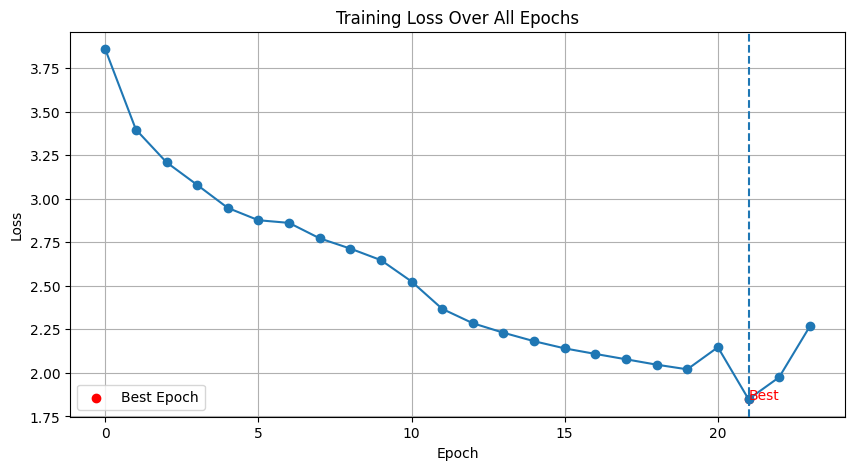

In [ ]:
import matplotlib.pyplot as plt

loss_all = [
    # phase 1
    3.8585,3.3973,3.2091,3.0794,2.9472,2.8765,2.8612,2.7725,2.7136,2.6473,

    # phase 2
    2.5246,2.3675,2.2849,2.2304,2.1817,2.1405,2.1087,2.0779,2.0470,2.0203,

    # phase 3
    2.1472,1.8486,1.9749,2.2666
]

plt.figure(figsize=(10,5))
plt.plot(loss_all, marker='o')

plt.title("Training Loss Over All Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# highlight best
best_epoch = loss_all.index(min(loss_all))
plt.scatter(best_epoch, min(loss_all), color='red', label='Best Epoch')
plt.legend()
plt.axvline(x=best_epoch, linestyle='--')
plt.text(best_epoch, min(loss_all), "Best", color='red')
plt.show()

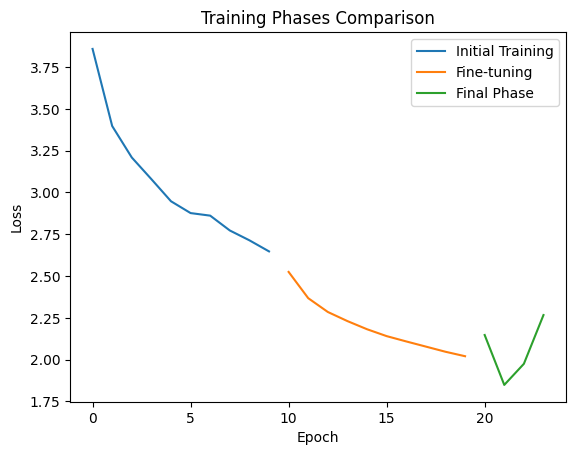

In [ ]:
phase1 = loss_all[:10]
phase2 = loss_all[10:20]
phase3 = loss_all[20:]

plt.plot(phase1, label="Initial Training")
plt.plot(range(10,20), phase2, label="Fine-tuning")
plt.plot(range(20,24), phase3, label="Final Phase")

plt.legend()
plt.title("Training Phases Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

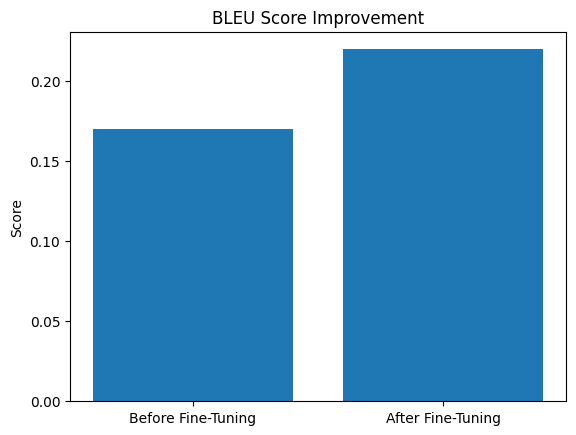

In [ ]:
bleu_scores = [0.17, 0.22]

labels = ["Before Fine-Tuning", "After Fine-Tuning"]

plt.bar(labels, bleu_scores)
plt.title("BLEU Score Improvement")
plt.ylabel("Score")
plt.show()

Mean BLEU: 0.2683504555316148


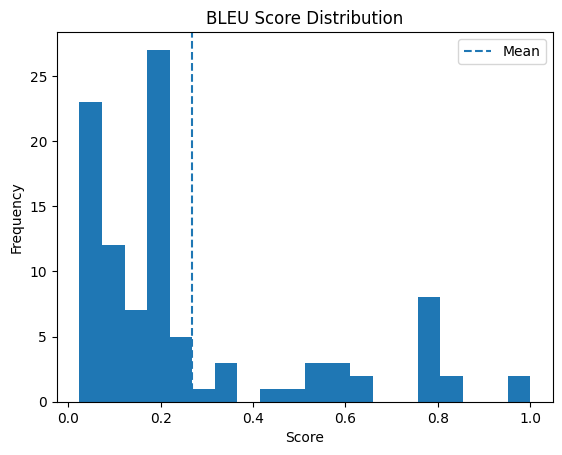

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

bleu_scores = []

for vid in list(captions.keys())[:100]:

    if vid not in features:
        continue

    feature = np.expand_dims(features[vid], axis=0)

    pred = generate_caption(model, feature, w2i, i2w, max_len)
    pred = clean_output(pred).split()

    refs = [c.replace("<start>", "").replace("<end>", "").split() for c in captions[vid]]

    score = sentence_bleu(refs, pred, smoothing_function=smooth)
    bleu_scores.append(score)

import matplotlib.pyplot as plt

plt.hist(bleu_scores, bins=20)
plt.title("BLEU Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
import numpy as np

mean_score = np.mean(bleu_scores)
plt.axvline(mean_score, linestyle='--', label='Mean')
plt.legend()
print("Mean BLEU:", mean_score)
plt.show()

In [ ]:
import pickle

with open("w2i.pkl", "wb") as f:
    pickle.dump(w2i, f)

with open("i2w.pkl", "wb") as f:
    pickle.dump(i2w, f)

In [ ]:
import pickle

with open("/content/drive/MyDrive/w2i.pkl", "wb") as f:
    pickle.dump(w2i, f)

with open("/content/drive/MyDrive/i2w.pkl", "wb") as f:
    pickle.dump(i2w, f)

print("Saved successfully!")

Saved successfully!
